In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import gpplot as gpp
from rs3.seq import predict_seq
import random
from zipfile import ZipFile
import scipy
from statsmodels.stats.multitest import multipletests
gpp.set_aesthetics(context = 'paper')

In [2]:
#read in Set A reads
reads_A = pd.read_excel('../../Data/externalData/Dolcetto/sanson_et_al_2018_dolcetto_screens.xlsx',sheet_name = 0)
reads_A.columns = reads_A.iloc[0] + '_' + reads_A.iloc[1]
reads_A = reads_A.drop([0,1],axis=0).reset_index(drop=True)
reads_A = reads_A.rename(columns = {np.nan:'sgRNA Sequence','pDNA_pDNA':'pDNA'})
reads_A

/opt/miniconda3/envs/crispri/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,sgRNA Sequence,pDNA,HT29_RepA,HT29_RepB,HT29_RepC,A375_RepA,A375_RepB,A375_RepC
0,AAAAAAAAAATACTGAGAGA,503,264,231,275,483,608,337
1,AAAAAAAAGAGGAGGGACGG,821,184,255,115,181,250,123
2,AAAAAAAATTTCCTAGCGTG,304,61,148,207,213,319,247
3,AAAAAAACCAGCCTAGCTCG,457,246,220,199,558,505,314
4,AAAAAAACTGTCCCGCAACC,1108,581,305,593,1214,975,688
...,...,...,...,...,...,...,...,...
57045,TTTGTTTGTGTCCCTGGCCA,1069,733,446,541,1369,1026,619
57046,TTTTACCTTGTTCACATGGA,810,295,179,502,890,819,338
57047,TTTTGACTCTAATCACCGGT,469,258,345,454,691,591,335
57048,TTTTTAATACAAGGTAATCT,481,216,401,442,517,710,468


In [3]:
#read in Set B reads
reads_B = pd.read_excel('../../Data/externalData/Dolcetto/sanson_et_al_2018_dolcetto_screens.xlsx',sheet_name = 1)
reads_B = reads_B.drop([0],axis=0).reset_index(drop=True)
reads_B.columns = reads_A.columns
reads_B

/opt/miniconda3/envs/crispri/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,sgRNA Sequence,pDNA,HT29_RepA,HT29_RepB,HT29_RepC,A375_RepA,A375_RepB,A375_RepC
0,AAAAAAAAAATTTCCTAGCG,257,275,201,187,394,137,155
1,AAAAAAAAAGCTGTGCGCAG,417,433,474,340,445,270,498
2,AAAAAAAACTGTCCCGCAAC,623,746,734,640,1182,784,642
3,AAAAAAAAGTGGTGGGGTGG,986,1108,1014,772,1474,628,492
4,AAAAAAAGAAAGAAACACAA,302,410,579,246,483,357,405
...,...,...,...,...,...,...,...,...
57006,TTTGTTGACACATGTGGTGC,888,967,1514,780,1035,973,742
57007,TTTGTTGTATAGCTGCAGAT,866,996,916,573,1118,1105,1245
57008,TTTGTTGTCTATGCCTTTAG,919,867,1093,900,1594,960,977
57009,TTTGTTTACTTGGCGAGACT,826,728,977,822,1131,694,667


In [4]:
#read in gene annotations (using NCBI annotations because DepMap essential/nonessential lists use NCBI annotations)
annotations_df_A = pd.read_table("../../Data/externalData/Dolcetto/CP0055_GRCh38_NCBI_CRISPRi_strict_gene_20240130.chip")
annotations_df_A = annotations_df_A.rename(columns = {'Barcode Sequence':'sgRNA Sequence'})

annotations_df_B = pd.read_table("../../Data/externalData/Dolcetto/CP0056_GRCh38_NCBI_CRISPRi_strict_gene_20240130.chip")
annotations_df_B = annotations_df_B.rename(columns = {'Barcode Sequence':'sgRNA Sequence'})

annotations_df = pd.concat([annotations_df_A,annotations_df_B],axis=0).reset_index(drop=True)
annotations_df

,sgRNA Sequence,Gene Symbol,Gene ID
0,AAAAAAAAAATACTGAGAGA,GATA3,2625
1,AAAAAAAAGAGGAGGGACGG,ANKH,56172
2,AAAAAAAATTTCCTAGCGTG,POTENTIALLY_ACTIVE_1,POTENTIALLY_ACTIVE_1
3,AAAAAAACCAGCCTAGCTCG,JAG1,182
4,AAAAAAACTGTCCCGCAACC,MAP1LC3C,440738
...,...,...,...
120503,TTTGTTGACACATGTGGTGC,ONE_INTERGENIC_SITE_1584,ONE_INTERGENIC_SITE_1584
120504,TTTGTTGTATAGCTGCAGAT,GABRA1,2554
120505,TTTGTTGTCTATGCCTTTAG,HABP2,3026
120506,TTTGTTTACTTGGCGAGACT,H2BC1,255626


In [5]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads

In [6]:
condition_columns = reads_A.columns[1:]
lognorm_df_A = reads_A.copy()
for column in condition_columns:
    lognorm_df_A[column] = lognorm_df_A[column].astype(float)
lognorm_df_A[condition_columns] = lognorm_df_A[condition_columns].apply(lognorm)
lognorm_df_A

,sgRNA Sequence,pDNA,HT29_RepA,HT29_RepB,HT29_RepC,A375_RepA,A375_RepB,A375_RepC
0,AAAAAAAAAATACTGAGAGA,3.373761,3.539097,3.488524,3.309694,3.639683,3.916153,3.857689
1,AAAAAAAAGAGGAGGGACGG,4.025644,3.071240,3.618980,2.241329,2.404901,2.764751,2.567114
2,AAAAAAAATTTCCTAGCGTG,2.735620,1.788645,2.916569,2.946915,2.598247,3.069717,3.445264
3,AAAAAAACCAGCCTAGCTCG,3.249339,3.446270,3.424547,2.897555,3.832282,3.667726,3.762976
4,AAAAAAACTGTCCCGCAACC,4.435019,4.607742,3.857912,4.338081,4.897918,4.561057,4.835663
...,...,...,...,...,...,...,...,...
57045,TTTGTTTGTGTCCCTGGCCA,4.385754,4.930694,4.374342,4.212518,5.065783,4.631572,4.688815
57046,TTTTACCTTGTTCACATGGA,4.007386,3.686173,3.157455,4.110609,4.467536,4.321113,3.861669
57047,TTTTGACTCTAATCACCGGT,3.282845,3.508813,4.024117,3.974417,4.121075,3.877986,3.849696
57048,TTTTTAATACAAGGTAATCT,3.315591,3.276909,4.228686,3.938261,3.730191,4.126106,4.303320


In [7]:
lognorm_df_B = reads_B.copy()
for column in condition_columns:
    lognorm_df_B[column] = lognorm_df_B[column].astype(float)
lognorm_df_B[condition_columns] = lognorm_df_B[condition_columns].apply(lognorm)
lognorm_df_B

,sgRNA Sequence,pDNA,HT29_RepA,HT29_RepB,HT29_RepC,A375_RepA,A375_RepB,A375_RepC
0,AAAAAAAAAATTTCCTAGCG,2.812728,2.505499,2.160707,2.484273,2.824756,1.982113,2.287247
1,AAAAAAAAAGCTGTGCGCAG,3.429989,3.064615,3.199459,3.225815,2.976838,2.768771,3.751683
2,AAAAAAAACTGTCCCGCAAC,3.964220,3.775196,3.773620,4.064193,4.267148,4.160745,4.093885
3,AAAAAAAAGTGGTGGGGTGG,4.592138,4.311062,4.210399,4.319900,4.570735,3.860555,3.735501
4,AAAAAAAGAAAGAAACACAA,3.014583,2.995512,3.459370,2.816692,3.080565,3.119204,3.477846
...,...,...,...,...,...,...,...,...
57006,TTTGTTGACACATGTGGTGC,4.447696,4.125251,4.762737,4.334032,4.086151,4.456577,4.291299
57007,TTTGTTGTATAGCTGCAGAT,4.413182,4.165472,4.072074,3.914706,4.191121,4.632242,5.007873
57008,TTTGTTGTCTATGCCTTTAG,4.494969,3.977271,4.312991,4.530913,4.679072,4.438062,4.670405
57009,TTTGTTTACTTGGCGAGACT,4.348232,3.742562,4.159720,4.406037,4.206892,3.995250,4.145828


<Axes: xlabel='pDNA', ylabel='Density'>

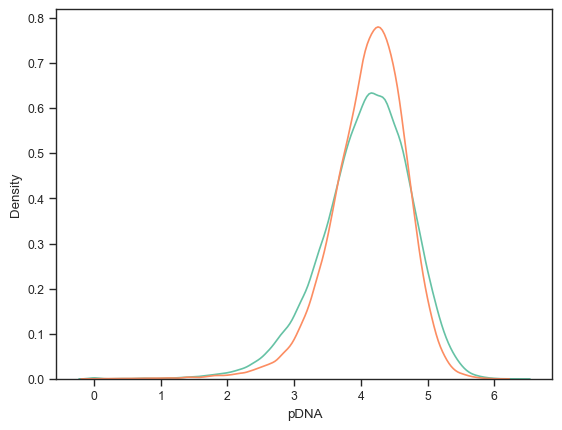

In [8]:
sns.kdeplot(data = lognorm_df_A, x = 'pDNA')
sns.kdeplot(data = lognorm_df_B, x = 'pDNA')

In [9]:
lognorm_df_A['set'] = 'A'
lognorm_df_B['set'] = 'B'
lognorm_df = pd.concat([lognorm_df_A,lognorm_df_B])
lognorm_df

,sgRNA Sequence,pDNA,HT29_RepA,HT29_RepB,HT29_RepC,A375_RepA,A375_RepB,A375_RepC,set
0,AAAAAAAAAATACTGAGAGA,3.373761,3.539097,3.488524,3.309694,3.639683,3.916153,3.857689,A
1,AAAAAAAAGAGGAGGGACGG,4.025644,3.071240,3.618980,2.241329,2.404901,2.764751,2.567114,A
2,AAAAAAAATTTCCTAGCGTG,2.735620,1.788645,2.916569,2.946915,2.598247,3.069717,3.445264,A
3,AAAAAAACCAGCCTAGCTCG,3.249339,3.446270,3.424547,2.897555,3.832282,3.667726,3.762976,A
4,AAAAAAACTGTCCCGCAACC,4.435019,4.607742,3.857912,4.338081,4.897918,4.561057,4.835663,A
...,...,...,...,...,...,...,...,...,...
57006,TTTGTTGACACATGTGGTGC,4.447696,4.125251,4.762737,4.334032,4.086151,4.456577,4.291299,B
57007,TTTGTTGTATAGCTGCAGAT,4.413182,4.165472,4.072074,3.914706,4.191121,4.632242,5.007873,B
57008,TTTGTTGTCTATGCCTTTAG,4.494969,3.977271,4.312991,4.530913,4.679072,4.438062,4.670405,B
57009,TTTGTTTACTTGGCGAGACT,4.348232,3.742562,4.159720,4.406037,4.206892,3.995250,4.145828,B


<Axes: xlabel='pDNA', ylabel='Density'>

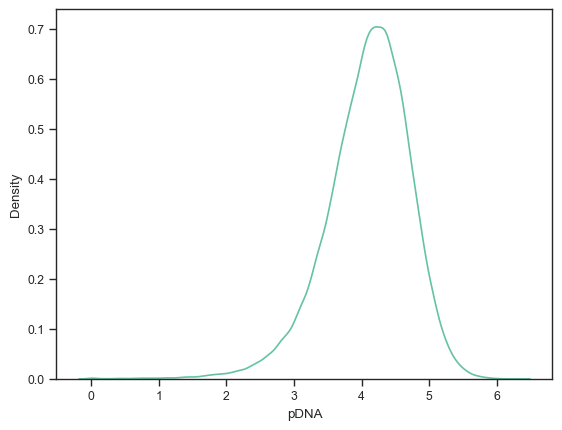

In [10]:
sns.kdeplot(data = lognorm_df, x = 'pDNA')

<Axes: xlabel='A375_RepA', ylabel='Density'>

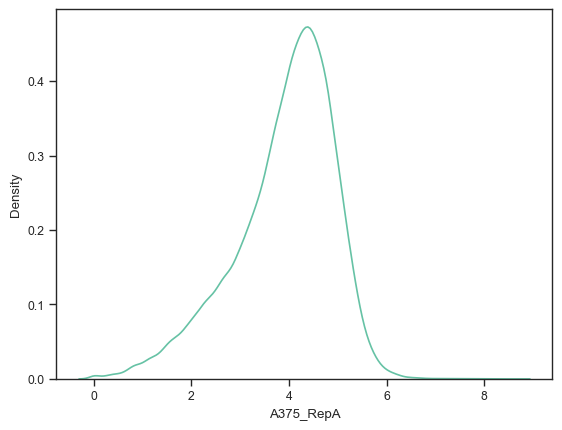

In [11]:
sns.kdeplot(data = lognorm_df, x = 'A375_RepA')

In [12]:
filtered_lognorms = lognorm_df.copy()
pdna_cols = ['pDNA']
z_low = -3  # minimum z-score
# Z-score the pDNA columns
z_scored_cols = []
for pdna in pdna_cols:
    z_col = pdna + '_z'
    filtered_lognorms[z_col] = (filtered_lognorms[pdna] - filtered_lognorms[pdna].mean())/filtered_lognorms[pdna].std()
    z_scored_cols.append(z_col)
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms[z_scored_cols].min(axis = 1) > z_low]
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop(z_scored_cols, axis=1)
filtered_lognorms

,sgRNA Sequence,pDNA,HT29_RepA,HT29_RepB,HT29_RepC,A375_RepA,A375_RepB,A375_RepC,set
0,AAAAAAAAAATACTGAGAGA,3.373761,3.539097,3.488524,3.309694,3.639683,3.916153,3.857689,A
1,AAAAAAAAGAGGAGGGACGG,4.025644,3.071240,3.618980,2.241329,2.404901,2.764751,2.567114,A
2,AAAAAAAATTTCCTAGCGTG,2.735620,1.788645,2.916569,2.946915,2.598247,3.069717,3.445264,A
3,AAAAAAACCAGCCTAGCTCG,3.249339,3.446270,3.424547,2.897555,3.832282,3.667726,3.762976,A
4,AAAAAAACTGTCCCGCAACC,4.435019,4.607742,3.857912,4.338081,4.897918,4.561057,4.835663,A
...,...,...,...,...,...,...,...,...,...
57006,TTTGTTGACACATGTGGTGC,4.447696,4.125251,4.762737,4.334032,4.086151,4.456577,4.291299,B
57007,TTTGTTGTATAGCTGCAGAT,4.413182,4.165472,4.072074,3.914706,4.191121,4.632242,5.007873,B
57008,TTTGTTGTCTATGCCTTTAG,4.494969,3.977271,4.312991,4.530913,4.679072,4.438062,4.670405,B
57009,TTTGTTTACTTGGCGAGACT,4.348232,3.742562,4.159720,4.406037,4.206892,3.995250,4.145828,B


In [13]:
print('Filtered ' + str(lognorm_df.shape[0] - filtered_lognorms.shape[0]) + ' sgRNAs with low pDNA')

Filtered 1045 sgRNAs with low pDNA


In [14]:
lfc_df = filtered_lognorms.copy()
target_cols = reads_A.columns[2:]
for target_col in target_cols:
    # use lognorm df in case columns double as target and ref
    lfc_df[target_col] = filtered_lognorms[target_col] - filtered_lognorms['pDNA']

# Remove reference column
lfc_df = lfc_df.drop('pDNA', axis=1)
lfc_df

,sgRNA Sequence,HT29_RepA,HT29_RepB,HT29_RepC,A375_RepA,A375_RepB,A375_RepC,set
0,AAAAAAAAAATACTGAGAGA,0.165336,0.114762,-0.064067,0.265921,0.542392,0.483928,A
1,AAAAAAAAGAGGAGGGACGG,-0.954404,-0.406664,-1.784315,-1.620743,-1.260893,-1.458530,A
2,AAAAAAAATTTCCTAGCGTG,-0.946974,0.180949,0.211295,-0.137373,0.334097,0.709644,A
3,AAAAAAACCAGCCTAGCTCG,0.196931,0.175208,-0.351784,0.582944,0.418388,0.513637,A
4,AAAAAAACTGTCCCGCAACC,0.172723,-0.577106,-0.096938,0.462899,0.126038,0.400645,A
...,...,...,...,...,...,...,...,...
57006,TTTGTTGACACATGTGGTGC,-0.322445,0.315041,-0.113664,-0.361545,0.008881,-0.156397,B
57007,TTTGTTGTATAGCTGCAGAT,-0.247710,-0.341107,-0.498476,-0.222061,0.219060,0.594691,B
57008,TTTGTTGTCTATGCCTTTAG,-0.517699,-0.181979,0.035944,0.184103,-0.056908,0.175436,B
57009,TTTGTTTACTTGGCGAGACT,-0.605670,-0.188512,0.057805,-0.141340,-0.352982,-0.202404,B


<Axes: xlabel='A375_RepA', ylabel='Density'>

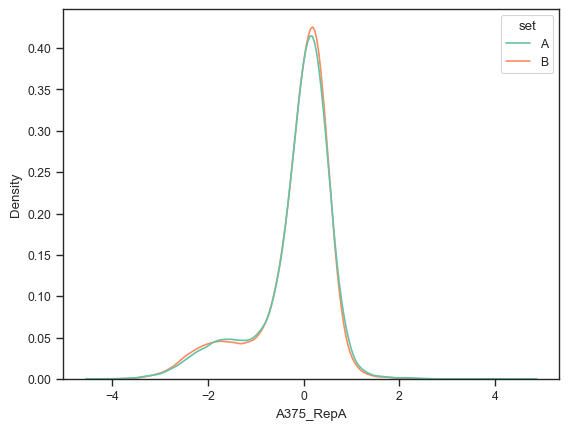

In [15]:
sns.kdeplot(data = lfc_df, x = 'A375_RepA', hue = 'set')

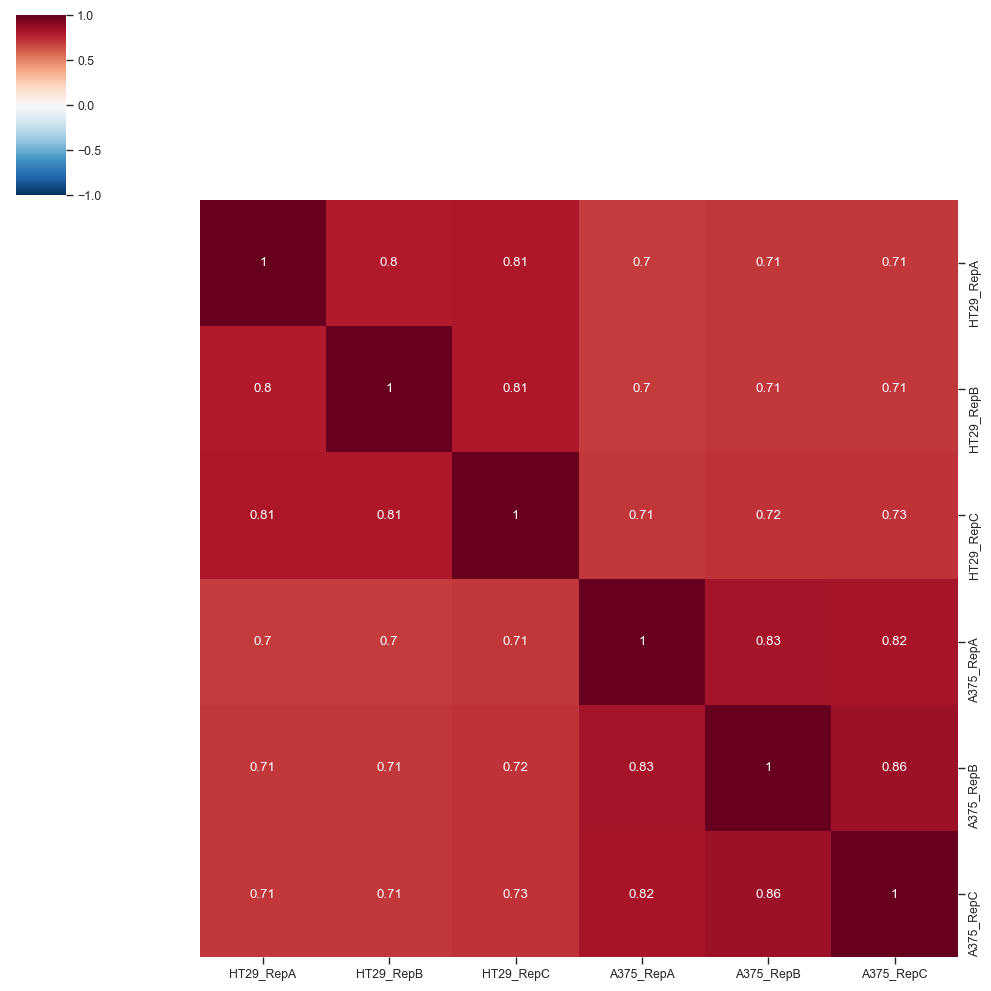

In [16]:
#check replicate correlation
lfc_correlations = lfc_df.corr(numeric_only=True)
sns.clustermap(lfc_correlations, cmap='RdBu_r',
               vmin=-1, vmax=1, annot=True,row_cluster=False,col_cluster=False)

In [17]:
long_lfcs = (lfc_df.melt(id_vars=['sgRNA Sequence','set'],
                         var_name='sample', value_name='lfc'))
long_lfcs[['cell_line','rep']] = long_lfcs['sample'].str.split('_',expand=True)
avg_lfcs = (long_lfcs.groupby(['set','cell_line','sgRNA Sequence'])
            .agg(avg_lfc = ('lfc', 'mean'),
                 n_obs = ('lfc', 'count'))
            .reset_index())
avg_lfcs['set_cell_line'] = avg_lfcs['set'] + '_' + avg_lfcs['cell_line']

annotated_sgrna_lfcs = (avg_lfcs.merge(annotations_df,
                                           how='inner',
                                           on='sgRNA Sequence'))
annotated_sgrna_lfcs

,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Gene Symbol,Gene ID
0,A,A375,AAAAAAAAAATACTGAGAGA,0.430747,3,A_A375,GATA3,2625
1,A,HT29,AAAAAAAAAATACTGAGAGA,0.072010,3,A_HT29,GATA3,2625
2,A,A375,AAAAAAAAGAGGAGGGACGG,-1.446722,3,A_A375,ANKH,56172
3,A,HT29,AAAAAAAAGAGGAGGGACGG,-1.048461,3,A_HT29,ANKH,56172
4,A,A375,AAAAAAAATTTCCTAGCGTG,0.302123,3,A_A375,POTENTIALLY_ACTIVE_1,POTENTIALLY_ACTIVE_1
...,...,...,...,...,...,...,...,...
238841,B,HT29,TTTGTTGTCTATGCCTTTAG,-0.221244,3,B_HT29,HABP2,3026
238842,B,A375,TTTGTTTACTTGGCGAGACT,-0.232242,3,B_A375,H2BC1,255626
238843,B,HT29,TTTGTTTACTTGGCGAGACT,-0.245459,3,B_HT29,H2BC1,255626
238844,B,A375,TTTGTTTCAAAGGGCAGAGA,0.237072,3,B_A375,C1orf116,79098


In [18]:
control_sgrna_lfcs = (annotated_sgrna_lfcs[(annotated_sgrna_lfcs['Gene Symbol']
                                            .str.contains('ONE_INTERGENIC'))]
                      .reset_index(drop=True))
control_sgrna_lfcs

,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Gene Symbol,Gene ID
0,A,A375,AAAAACCAGAATATTGTGAT,0.685217,3,A_A375,ONE_INTERGENIC_SITE_1,ONE_INTERGENIC_SITE_1
1,A,HT29,AAAAACCAGAATATTGTGAT,0.300787,3,A_HT29,ONE_INTERGENIC_SITE_1,ONE_INTERGENIC_SITE_1
2,A,A375,AAAAAGAATTAAGAGAGACA,0.350826,3,A_A375,ONE_INTERGENIC_SITE_2,ONE_INTERGENIC_SITE_2
3,A,HT29,AAAAAGAATTAAGAGAGACA,0.070279,3,A_HT29,ONE_INTERGENIC_SITE_2,ONE_INTERGENIC_SITE_2
4,A,A375,AAAAAGATCAAAGCAAAATT,0.443929,3,A_A375,ONE_INTERGENIC_SITE_3,ONE_INTERGENIC_SITE_3
...,...,...,...,...,...,...,...,...
6339,B,HT29,TTTGATGGTAGTGAGATTAA,-0.104320,3,B_HT29,ONE_INTERGENIC_SITE_1582,ONE_INTERGENIC_SITE_1582
6340,B,A375,TTTGATTTCCTGTTTCCATG,0.208661,3,B_A375,ONE_INTERGENIC_SITE_1583,ONE_INTERGENIC_SITE_1583
6341,B,HT29,TTTGATTTCCTGTTTCCATG,0.251669,3,B_HT29,ONE_INTERGENIC_SITE_1583,ONE_INTERGENIC_SITE_1583
6342,B,A375,TTTGTTGACACATGTGGTGC,-0.169687,3,B_A375,ONE_INTERGENIC_SITE_1584,ONE_INTERGENIC_SITE_1584


<Axes: xlabel='avg_lfc', ylabel='Density'>

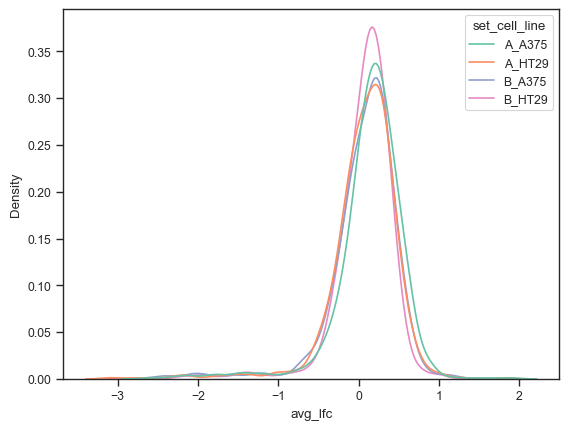

In [19]:
sns.kdeplot(data = control_sgrna_lfcs, x = 'avg_lfc', hue = 'set_cell_line')

<Axes: xlabel='avg_lfc', ylabel='Density'>

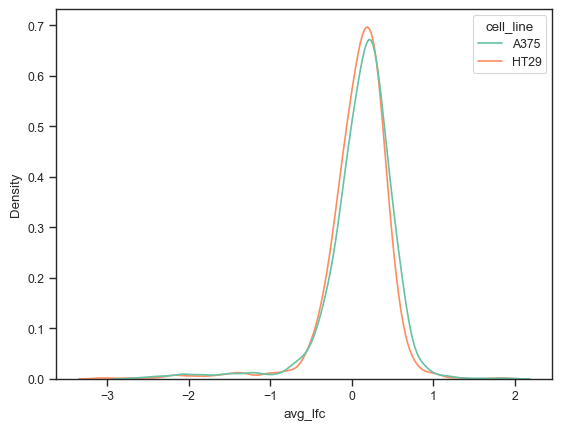

In [20]:
sns.kdeplot(data = control_sgrna_lfcs, x = 'avg_lfc', hue = 'cell_line')

In [21]:
control_sgrna_stats = control_sgrna_lfcs.groupby(['cell_line']).agg(neg_ctl_mean = ('avg_lfc','mean'),
                                                                    neg_ctl_sd = ('avg_lfc','std')).reset_index()
control_sgrna_stats

,cell_line,neg_ctl_mean,neg_ctl_sd
0,A375,0.106539,0.437645
1,HT29,0.072995,0.413134


In [22]:
zscored_sgrna_lfcs = annotated_sgrna_lfcs.merge(control_sgrna_stats, on = ['cell_line'])
zscored_sgrna_lfcs['z_scored_avg_lfc'] = ((zscored_sgrna_lfcs['avg_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs

,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Gene Symbol,Gene ID,neg_ctl_mean,neg_ctl_sd,z_scored_avg_lfc
0,A,A375,AAAAAAAAAATACTGAGAGA,0.430747,3,A_A375,GATA3,2625,0.106539,0.437645,0.740801
1,A,A375,AAAAAAAAGAGGAGGGACGG,-1.446722,3,A_A375,ANKH,56172,0.106539,0.437645,-3.549133
2,A,A375,AAAAAAAATTTCCTAGCGTG,0.302123,3,A_A375,POTENTIALLY_ACTIVE_1,POTENTIALLY_ACTIVE_1,0.106539,0.437645,0.446901
3,A,A375,AAAAAAACCAGCCTAGCTCG,0.504990,3,A_A375,JAG1,182,0.106539,0.437645,0.910442
4,A,A375,AAAAAAACTGTCCCGCAACC,0.329861,3,A_A375,MAP1LC3C,440738,0.106539,0.437645,0.510280
...,...,...,...,...,...,...,...,...,...,...,...
238841,B,HT29,TTTGTTGACACATGTGGTGC,-0.040356,3,B_HT29,ONE_INTERGENIC_SITE_1584,ONE_INTERGENIC_SITE_1584,0.072995,0.413134,-0.274369
238842,B,HT29,TTTGTTGTATAGCTGCAGAT,-0.362431,3,B_HT29,GABRA1,2554,0.072995,0.413134,-1.053958
238843,B,HT29,TTTGTTGTCTATGCCTTTAG,-0.221244,3,B_HT29,HABP2,3026,0.072995,0.413134,-0.712212
238844,B,HT29,TTTGTTTACTTGGCGAGACT,-0.245459,3,B_HT29,H2BC1,255626,0.072995,0.413134,-0.770825


In [24]:
zip_file = ZipFile('../../Data/CRISPickRuns/sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt.zip')
crispri_genomewide_design = pd.read_table(zip_file.open('sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt'))
crispri_genomewide_design

/var/folders/mj/lhpd16ys0cx2wkbhm7s0nfcm0000gp/T/ipykernel_5294/689400535.py:2: DtypeWarning: Columns (24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  crispri_genomewide_design = pd.read_table(zip_file.open('sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt'))


,Input,Quota,Target Taxon,Target Gene ID,Target Gene Symbol,Target Alias,CRISPR Mechanism,Target Domain,Reference Sequence,Strand of Target,...,Seed Score (v1),Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Ruleset,On-Target Efficacy Score,ATAC-seq Score,On-Target Rank,Pick Order,Picking Round,Picking Notes
0,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.7330,0.8571,1,1.0,1.0,NaN
1,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,2.0,0,0,RS3i-Chen2013,1.6820,0.8571,2,2.0,1.0,NaN
2,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.6170,0.8571,3,3.0,1.0,NaN
3,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.5020,0.8571,4,4.0,1.0,NaN
4,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.4470,0.8571,5,NaN,NaN,BsmBI:GAGACG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594931,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,2.0,0,0,RS3i-Chen2013,-0.3301,1.0000,67,52.0,5.0,Previously skipped due to: On-Target Efficacy ...
1594932,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,1.0,0,0,RS3i-Chen2013,-0.3342,1.0000,68,53.0,5.0,Previously skipped due to: On-Target Efficacy ...
1594933,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,4.0,0,0,RS3i-Chen2013,-0.3360,1.0000,69,71.0,8.0,Previously skipped due to: On-Target Efficacy ...
1594934,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,2.0,0,0,RS3i-Chen2013,-0.4603,1.0000,70,54.0,5.0,Previously skipped due to: On-Target Efficacy ...


In [25]:
#merge with genome wide crispick design run to get TSS offset, ATAC-seq overlap
merged_sgrna_design = zscored_sgrna_lfcs.merge(crispri_genomewide_design,
                                                 left_on = 'sgRNA Sequence',
                                                 right_on = 'sgRNA Sequence',
                                                 how = 'inner').reset_index(drop=True)
merged_sgrna_design

,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Gene Symbol,Gene ID,neg_ctl_mean,neg_ctl_sd,...,Seed Score (v1),Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Ruleset,On-Target Efficacy Score,ATAC-seq Score,On-Target Rank,Pick Order,Picking Round,Picking Notes
0,A,A375,AAAAAAAAAATACTGAGAGA,0.430747,3,A_A375,GATA3,2625,0.106539,0.437645,...,0.0,0,0,RS3i-Chen2013,0.78110,0.5714,11,9.0,5.0,Previously skipped due to: On-Target Efficacy ...
1,A,HT29,AAAAAAAAAATACTGAGAGA,0.072010,3,A_HT29,GATA3,2625,0.072995,0.413134,...,0.0,0,0,RS3i-Chen2013,0.78110,0.5714,11,9.0,5.0,Previously skipped due to: On-Target Efficacy ...
2,A,A375,AAAAAAAAGAGGAGGGACGG,-1.446722,3,A_A375,ANKH,56172,0.106539,0.437645,...,4.0,0,0,RS3i-Chen2013,1.17500,1.0000,8,63.0,8.0,Previously skipped due to: On-Target Efficacy ...
3,A,HT29,AAAAAAAAGAGGAGGGACGG,-1.048461,3,A_HT29,ANKH,56172,0.072995,0.413134,...,4.0,0,0,RS3i-Chen2013,1.17500,1.0000,8,63.0,8.0,Previously skipped due to: On-Target Efficacy ...
4,A,A375,AAAAAAAATTTCCTAGCGTG,0.302123,3,A_A375,POTENTIALLY_ACTIVE_1,POTENTIALLY_ACTIVE_1,0.106539,0.437645,...,0.0,0,0,RS3i-Chen2013,0.79580,1.0000,18,16.0,5.0,Previously skipped due to: On-Target Efficacy ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255767,B,HT29,TTTGTTGTCTATGCCTTTAG,-0.221244,3,B_HT29,HABP2,3026,0.072995,0.413134,...,0.0,0,0,RS3i-Chen2013,0.09537,0.1429,28,24.0,5.0,Previously skipped due to: On-Target Efficacy ...
255768,B,A375,TTTGTTTACTTGGCGAGACT,-0.232242,3,B_A375,H2BC1,255626,0.106539,0.437645,...,1.0,0,0,RS3i-Chen2013,0.10320,0.1429,27,25.0,5.0,Previously skipped due to: On-Target Efficacy ...
255769,B,HT29,TTTGTTTACTTGGCGAGACT,-0.245459,3,B_HT29,H2BC1,255626,0.072995,0.413134,...,1.0,0,0,RS3i-Chen2013,0.10320,0.1429,27,25.0,5.0,Previously skipped due to: On-Target Efficacy ...
255770,B,A375,TTTGTTTCAAAGGGCAGAGA,0.237072,3,B_A375,C1orf116,79098,0.106539,0.437645,...,2.0,0,0,RS3i-Chen2013,0.53870,0.7143,27,23.0,5.0,Previously skipped due to: On-Target Efficacy ...


### Format for RS3i Validation

In [26]:
rs3i_input = merged_sgrna_design.groupby(['sgRNA Context Sequence',
                                          'Gene ID',
                                          'Target Gene Symbol',
                                          'sgRNA \'Cut\' Site TSS Offset',
                                          'ATAC-seq Score'])['z_scored_avg_lfc'].mean().dropna().reset_index()
rs3i_input

,sgRNA Context Sequence,Gene ID,Target Gene Symbol,sgRNA 'Cut' Site TSS Offset,ATAC-seq Score,z_scored_avg_lfc
0,AAAAAAAAAAAAAATACTGAGAGAGGGAGA,2625,GATA3,78,0.5714,0.369209
1,AAAAAAAAAAAAGTGGTGGGGTGGAGGTCA,100130733,LRRC70,-2,0.2857,-1.200267
2,AAAAAAAAAAAAGTGGTGGGGTGGAGGTCA,101180901,LRRC70,-2,0.2857,-1.200267
3,AAAAAAAAAAACCAGCCTAGCTCGCGGGCC,182,JAG1,74,1.0000,0.375090
4,AAAAAAAAAAAGAAAGGGGAAAGGGGGGAA,10983,CCNI,72,1.0000,0.688428
...,...,...,...,...,...,...
125852,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,100381270,ZBED6,205,1.0000,0.047840
125853,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,100381270,ZC3H11A,205,1.0000,0.047840
125854,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,9877,ZBED6,205,1.0000,0.047840
125855,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,9877,ZC3H11A,205,1.0000,0.047840


In [27]:
essential_genes = pd.read_csv('../../Data/essentialNonessentialAnnotations/AchillesCommonEssentialControls.csv').Gene
essential_gene_ids = essential_genes.str.split('(',expand=True)[1].str[:-1]
essential_gene_ids

0          14
1          16
2       60496
3          22
4        6059
        ...  
1242    55628
1243    64763
1244    90441
1245    54680
1246    26009
Name: 1, Length: 1247, dtype: object

In [28]:
dolcetto_ess = rs3i_input[rs3i_input['Gene ID'].isin(essential_gene_ids)].reset_index(drop=True)
dolcetto_ess['rs3ChenSeqScore'] = predict_seq(dolcetto_ess['sgRNA Context Sequence'], sequence_tracr='Chen2013')
dolcetto_ess

Calculating sequence-based features


100%|██████████████████████████████████████| 7517/7517 [00:11<00:00, 631.97it/s]


,sgRNA Context Sequence,Gene ID,Target Gene Symbol,sgRNA 'Cut' Site TSS Offset,ATAC-seq Score,z_scored_avg_lfc,rs3ChenSeqScore
0,AAAAAAGGCATGAGGGGTCGTCTTCGGAAT,11243,PMF1,72,1.0,-4.488167,0.280793
1,AAAAAAGGCATGAGGGGTCGTCTTCGGAAT,11243,PMF1-BGLAP,72,1.0,-4.488167,0.280793
2,AAAAAGAAAAAAGTGTCATTGGCGTGGAGT,374354,NHLRC2,82,1.0,0.495681,-0.554033
3,AAAACCCCAAAGCTTCCCTACCAAGGGAAA,4863,NPAT,221,1.0,-0.347654,-0.266440
4,AAAACGTCTGTGAGCCCACACGACCGGCTG,440138,ALG11,65,1.0,-5.389098,0.258521
...,...,...,...,...,...,...,...
7512,TTTTCGCGGGCAGAGGCGCGCAGTCGGCGC,51750,RTEL1,23,1.0,-3.625019,-0.131643
7513,TTTTCTGCCTGAAGAAGCGTCATACGGACC,387103,CENPW,58,1.0,-4.887795,-0.010349
7514,TTTTGAATCGGTTGTGGCGGCCGCCGGCGA,1894,ECT2,53,1.0,-5.366770,-0.225873
7515,TTTTGTTCCACAGACTCGGAAGAAAGGTTG,57721,METTL14,73,1.0,-3.325580,0.154065


In [29]:
#remove overlapping genes
overlapping_genes = pd.read_csv('../../Data/geneOverlap/GW_ensembl_protein_coding_df_1kb.csv')
overlapping_gene_2_3 = overlapping_genes[overlapping_genes['overlap type'].isin([2,3])]
gene_2_3_unique = set(list(overlapping_gene_2_3['Selected Gene name']) +\
list(overlapping_gene_2_3['Overlapping Gene name']))
dolcetto_ess_nonoverlapping = dolcetto_ess[~dolcetto_ess['Target Gene Symbol'].isin(gene_2_3_unique)]
dolcetto_ess_nonoverlapping

,sgRNA Context Sequence,Gene ID,Target Gene Symbol,sgRNA 'Cut' Site TSS Offset,ATAC-seq Score,z_scored_avg_lfc,rs3ChenSeqScore
7,AAAAGAGGGCCCAAGCCCGGGCCGCGGTGC,1650,DDOST,38,1.0,0.198303,-1.500172
9,AAAAGCAGCAACGCTAACGGAAAAGGGCCG,10972,TMED10,65,1.0,-3.709076,-0.519706
10,AAAAGCGGGCGAGTTGGTAACCAGGGGGAA,27107,ZBTB11,45,1.0,-5.745916,0.420246
11,AAAAGGAAACCCGCTAAAGAAAATGGGCCG,6872,TAF1,61,1.0,-0.217333,0.013217
12,AAAAGGCCGTACCCGGCAGGCTGGCGGGCG,55677,IWS1,70,1.0,-1.038025,0.059319
...,...,...,...,...,...,...,...
7510,TTTTCCGGAGGCAGCCATGATACGCGGCAA,51106,TFB1M,53,1.0,-3.155509,0.346908
7511,TTTTCCTTCAGGACCAGAGCTGAGAGGAGC,134430,WDR36,83,1.0,-3.612574,0.396354
7513,TTTTCTGCCTGAAGAAGCGTCATACGGACC,387103,CENPW,58,1.0,-4.887795,-0.010349
7514,TTTTGAATCGGTTGTGGCGGCCGCCGGCGA,1894,ECT2,53,1.0,-5.366770,-0.225873


In [30]:
X_test = dolcetto_ess_nonoverlapping[['Gene ID','sgRNA Context Sequence','sgRNA \'Cut\' Site TSS Offset', 'rs3ChenSeqScore','z_scored_avg_lfc']].copy()
X_test.loc[:,'rs3ChenSeqScore'] = round(X_test['rs3ChenSeqScore'],4)
X_test.loc[:,'sgRNA \'Cut\' Site TSS Offset'] = X_test['sgRNA \'Cut\' Site TSS Offset'].astype(int)
X_test['ATAC_overlap_with_peak'] = pd.cut(dolcetto_ess['ATAC-seq Score'],bins=[0,0.5,1,np.inf],right=False)

# one-hot encoding
X_test_encoded = pd.get_dummies(X_test, columns=['ATAC_overlap_with_peak'])

bool_cols = X_test_encoded.select_dtypes(include=['bool']).columns.tolist()
X_test_encoded[bool_cols] = X_test_encoded[bool_cols].astype(int)

def clean_column_name(name):
    return (
        str(name)
        .replace('[', '_')
        .replace(']', '_')
        .replace('<', '_')
        .replace('>', '_')
        .replace(' ', '_')
        .replace(',', '_')
        .replace('(', '_')
        .replace(')', '_')
    )

X_test_encoded.columns = [clean_column_name(col) for col in X_test_encoded.columns]
X_test_encoded

,Gene_ID,sgRNA_Context_Sequence,sgRNA_'Cut'_Site_TSS_Offset,rs3ChenSeqScore,z_scored_avg_lfc,ATAC_overlap_with_peak__0.0__0.5_,ATAC_overlap_with_peak__0.5__1.0_,ATAC_overlap_with_peak__1.0__inf_
7,1650,AAAAGAGGGCCCAAGCCCGGGCCGCGGTGC,38,-1.5002,0.198303,0,0,1
9,10972,AAAAGCAGCAACGCTAACGGAAAAGGGCCG,65,-0.5197,-3.709076,0,0,1
10,27107,AAAAGCGGGCGAGTTGGTAACCAGGGGGAA,45,0.4202,-5.745916,0,0,1
11,6872,AAAAGGAAACCCGCTAAAGAAAATGGGCCG,61,0.0132,-0.217333,0,0,1
12,55677,AAAAGGCCGTACCCGGCAGGCTGGCGGGCG,70,0.0593,-1.038025,0,0,1
...,...,...,...,...,...,...,...,...
7510,51106,TTTTCCGGAGGCAGCCATGATACGCGGCAA,53,0.3469,-3.155509,0,0,1
7511,134430,TTTTCCTTCAGGACCAGAGCTGAGAGGAGC,83,0.3964,-3.612574,0,0,1
7513,387103,TTTTCTGCCTGAAGAAGCGTCATACGGACC,58,-0.0103,-4.887795,0,0,1
7514,1894,TTTTGAATCGGTTGTGGCGGCCGCCGGCGA,53,-0.2259,-5.366770,0,0,1


In [31]:
X_test_encoded.to_csv('../../Data/externalData/Dolcetto/dolcetto_rs3i_input_a375_ht29_average.csv',index=False)

### Format for Seed Score Validation

In [32]:
nonessential_genes = pd.read_csv('../../Data/essentialNonessentialAnnotations/AchillesNonessentialControls.csv').Gene
nonessential_gene_ids = nonessential_genes.str.split('(',expand=True)[1].str[:-1]
nonessential_gene_ids

0       64241
1      390110
2       10881
3       10880
4      284382
        ...  
776    219578
777    148066
778      7783
779     57829
780    151112
Name: 1, Length: 781, dtype: object

In [33]:
seed_score_input = merged_sgrna_design.groupby(['sgRNA Context Sequence',
                                                'sgRNA Sequence',
                                                'Gene ID',
                                                'Target Gene Symbol'])['z_scored_avg_lfc'].mean().reset_index()
seed_score_input

,sgRNA Context Sequence,sgRNA Sequence,Gene ID,Target Gene Symbol,z_scored_avg_lfc
0,AAAAAAAAAAAAAATACTGAGAGAGGGAGA,AAAAAAAAAATACTGAGAGA,2625,GATA3,0.369209
1,AAAAAAAAAAAAGTGGTGGGGTGGAGGTCA,AAAAAAAAGTGGTGGGGTGG,100130733,LRRC70,-1.200267
2,AAAAAAAAAAAAGTGGTGGGGTGGAGGTCA,AAAAAAAAGTGGTGGGGTGG,101180901,LRRC70,-1.200267
3,AAAAAAAAAAACCAGCCTAGCTCGCGGGCC,AAAAAAACCAGCCTAGCTCG,182,JAG1,0.375090
4,AAAAAAAAAAAGAAAGGGGAAAGGGGGGAA,AAAAAAAGAAAGGGGAAAGG,10983,CCNI,0.688428
...,...,...,...,...,...
125677,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,TTTGATTCCCGGGTGGCTTG,100381270,ZBED6,0.047840
125678,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,TTTGATTCCCGGGTGGCTTG,100381270,ZC3H11A,0.047840
125679,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,TTTGATTCCCGGGTGGCTTG,9877,ZBED6,0.047840
125680,TTTTTTTGATTCCCGGGTGGCTTGGGGCCG,TTTGATTCCCGGGTGGCTTG,9877,ZC3H11A,0.047840


In [34]:
dolcetto_noness = seed_score_input[seed_score_input['Gene ID'].isin(nonessential_gene_ids)].reset_index(drop=True)
dolcetto_noness

,sgRNA Context Sequence,sgRNA Sequence,Gene ID,Target Gene Symbol,z_scored_avg_lfc
0,AAAAAAAAAACAACGAACTCCATCTGGGAT,AAAAAACAACGAACTCCATC,54363,HAO1,-0.405955
1,AAAAAAAAACTTACCAACCAGAAAAGGCCC,AAAAACTTACCAACCAGAAA,259239,WFDC11,-0.687866
2,AAAAAAAGAAACAAGACCAAACTCTGGTCT,AAAGAAACAAGACCAAACTC,219986,OR4D11,0.784696
3,AAAAAAATTCCATTGGAAACTGATTGGGCA,AAATTCCATTGGAAACTGAT,114026,ZIM3,-0.258203
4,AAAAAATTCCATTGGAAACTGATTGGGCAG,AATTCCATTGGAAACTGATT,114026,ZIM3,-0.700636
...,...,...,...,...,...
4318,TTTTTTAGCTAGCAGGCTTTATGGTGGCTG,TTAGCTAGCAGGCTTTATGG,168391,GALNTL5,-0.144799
4319,TTTTTTCAAAAAGTCTCAAAAATCAGGTTG,TTCAAAAAGTCTCAAAAATC,1758,DMP1,0.779832
4320,TTTTTTCATGTTCTCCTTGAGTGAAGGATG,TTCATGTTCTCCTTGAGTGA,84873,ADGRG7,-0.536158
4321,TTTTTTTAATTACTGATTAAATTTTGGTAC,TTTAATTACTGATTAAATTT,259239,WFDC11,-0.010779


In [35]:
#remove overlapping genes
overlapping_genes = pd.read_csv('../../Data/geneOverlap/GW_ensembl_protein_coding_df_1kb.csv')
overlapping_gene_2_3 = overlapping_genes[overlapping_genes['overlap type'].isin([2,3])]
gene_2_3_unique = set(list(overlapping_gene_2_3['Selected Gene name']) +\
list(overlapping_gene_2_3['Overlapping Gene name']))
dolcetto_noness_nonoverlapping = dolcetto_noness[~dolcetto_noness['Target Gene Symbol'].isin(gene_2_3_unique)]
dolcetto_noness_nonoverlapping

,sgRNA Context Sequence,sgRNA Sequence,Gene ID,Target Gene Symbol,z_scored_avg_lfc
0,AAAAAAAAAACAACGAACTCCATCTGGGAT,AAAAAACAACGAACTCCATC,54363,HAO1,-0.405955
1,AAAAAAAAACTTACCAACCAGAAAAGGCCC,AAAAACTTACCAACCAGAAA,259239,WFDC11,-0.687866
2,AAAAAAAGAAACAAGACCAAACTCTGGTCT,AAAGAAACAAGACCAAACTC,219986,OR4D11,0.784696
3,AAAAAAATTCCATTGGAAACTGATTGGGCA,AAATTCCATTGGAAACTGAT,114026,ZIM3,-0.258203
4,AAAAAATTCCATTGGAAACTGATTGGGCAG,AATTCCATTGGAAACTGATT,114026,ZIM3,-0.700636
...,...,...,...,...,...
4318,TTTTTTAGCTAGCAGGCTTTATGGTGGCTG,TTAGCTAGCAGGCTTTATGG,168391,GALNTL5,-0.144799
4319,TTTTTTCAAAAAGTCTCAAAAATCAGGTTG,TTCAAAAAGTCTCAAAAATC,1758,DMP1,0.779832
4320,TTTTTTCATGTTCTCCTTGAGTGAAGGATG,TTCATGTTCTCCTTGAGTGA,84873,ADGRG7,-0.536158
4321,TTTTTTTAATTACTGATTAAATTTTGGTAC,TTTAATTACTGATTAAATTT,259239,WFDC11,-0.010779


In [36]:
#remove low RS3 Sequence score guides
dolcetto_noness_nonoverlapping['rs3ChenSeqScore'] = predict_seq(dolcetto_noness_nonoverlapping['sgRNA Context Sequence'], sequence_tracr='Chen2013')
dolcetto_noness_nonoverlapping_active = dolcetto_noness_nonoverlapping[dolcetto_noness_nonoverlapping['rs3ChenSeqScore'] > -0.5].copy()
dolcetto_noness_nonoverlapping_active

Calculating sequence-based features


100%|██████████████████████████████████████| 4203/4203 [00:06<00:00, 643.57it/s]
/var/folders/mj/lhpd16ys0cx2wkbhm7s0nfcm0000gp/T/ipykernel_5294/548321927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dolcetto_noness_nonoverlapping['rs3ChenSeqScore'] = predict_seq(dolcetto_noness_nonoverlapping['sgRNA Context Sequence'], sequence_tracr='Chen2013')


,sgRNA Context Sequence,sgRNA Sequence,Gene ID,Target Gene Symbol,z_scored_avg_lfc,rs3ChenSeqScore
2,AAAAAAAGAAACAAGACCAAACTCTGGTCT,AAAGAAACAAGACCAAACTC,219986,OR4D11,0.784696,0.545465
4,AAAAAATTCCATTGGAAACTGATTGGGCAG,AATTCCATTGGAAACTGATT,114026,ZIM3,-0.700636,0.245527
5,AAAAAGTCTCCCAGAGATACTTACTGGATA,AGTCTCCCAGAGATACTTAC,6121,RPE65,0.090946,0.461185
7,AAAAATGGCCAATGGACTTTCCCATGGAAT,ATGGCCAATGGACTTTCCCA,127670,TEDDM1,-0.477513,0.774978
10,AAAAGAGTCCAAGCTTGTATCCACTGGAAT,GAGTCCAAGCTTGTATCCAC,3375,IAPP,-0.413411,0.877350
...,...,...,...,...,...,...
4314,TTTTGGGCAAACCATCTTCAGCCATGGGGC,GGGCAAACCATCTTCAGCCA,85438,CABS1,0.462711,-0.448457
4315,TTTTTATGAGAGTTCATTCAGTTTTGGAGA,TATGAGAGTTCATTCAGTTT,114026,ZIM3,-0.623005,-0.451196
4317,TTTTTGCCCACATAGCAGCTGTACCGGTAA,TGCCCACATAGCAGCTGTAC,4224,MEP1A,0.121200,0.752475
4318,TTTTTTAGCTAGCAGGCTTTATGGTGGCTG,TTAGCTAGCAGGCTTTATGG,168391,GALNTL5,-0.144799,0.850213


In [37]:
#remove genes that don't behave as nonessential
dolcetto_noness_nonoverlapping_active['gene_avg_zscore'] = dolcetto_noness_nonoverlapping_active.groupby('Gene ID')['z_scored_avg_lfc'].transform('mean')
dolcetto_noness_nonoverlapping_active = dolcetto_noness_nonoverlapping_active[dolcetto_noness_nonoverlapping_active['gene_avg_zscore'] > -2].copy()
dolcetto_noness_nonoverlapping_active

,sgRNA Context Sequence,sgRNA Sequence,Gene ID,Target Gene Symbol,z_scored_avg_lfc,rs3ChenSeqScore,gene_avg_zscore
2,AAAAAAAGAAACAAGACCAAACTCTGGTCT,AAAGAAACAAGACCAAACTC,219986,OR4D11,0.784696,0.545465,-0.136572
4,AAAAAATTCCATTGGAAACTGATTGGGCAG,AATTCCATTGGAAACTGATT,114026,ZIM3,-0.700636,0.245527,0.015397
5,AAAAAGTCTCCCAGAGATACTTACTGGATA,AGTCTCCCAGAGATACTTAC,6121,RPE65,0.090946,0.461185,0.602982
7,AAAAATGGCCAATGGACTTTCCCATGGAAT,ATGGCCAATGGACTTTCCCA,127670,TEDDM1,-0.477513,0.774978,-0.154337
10,AAAAGAGTCCAAGCTTGTATCCACTGGAAT,GAGTCCAAGCTTGTATCCAC,3375,IAPP,-0.413411,0.877350,-0.196855
...,...,...,...,...,...,...,...
4314,TTTTGGGCAAACCATCTTCAGCCATGGGGC,GGGCAAACCATCTTCAGCCA,85438,CABS1,0.462711,-0.448457,0.537773
4315,TTTTTATGAGAGTTCATTCAGTTTTGGAGA,TATGAGAGTTCATTCAGTTT,114026,ZIM3,-0.623005,-0.451196,0.015397
4317,TTTTTGCCCACATAGCAGCTGTACCGGTAA,TGCCCACATAGCAGCTGTAC,4224,MEP1A,0.121200,0.752475,0.413159
4318,TTTTTTAGCTAGCAGGCTTTATGGTGGCTG,TTAGCTAGCAGGCTTTATGG,168391,GALNTL5,-0.144799,0.850213,0.219042


In [38]:
dolcetto_intergenics = zscored_sgrna_lfcs[zscored_sgrna_lfcs['Gene ID'].str.contains('ONE_INTERGENIC')].copy()
dolcetto_intergenics = dolcetto_intergenics.groupby(['sgRNA Sequence',
                                                     'Gene ID'])['z_scored_avg_lfc'].mean().reset_index()
dolcetto_intergenics

,sgRNA Sequence,Gene ID,z_scored_avg_lfc
0,AAAAACCAGAATATTGTGAT,ONE_INTERGENIC_SITE_1,0.936814
1,AAAAAGAAAGCTTGCCAAGG,ONE_INTERGENIC_SITE_1,-0.405963
2,AAAAAGAATTAAGAGAGACA,ONE_INTERGENIC_SITE_2,0.275805
3,AAAAAGATCAAAGCAAAATT,ONE_INTERGENIC_SITE_3,0.340681
4,AAAAAGCATCCAGTGGAGAT,ONE_INTERGENIC_SITE_2,-1.075399
...,...,...,...
3167,TTTGGTCCAAAGGGGATGGA,ONE_INTERGENIC_SITE_1605,-0.486171
3168,TTTGGTGAGTTTATTCTACT,ONE_INTERGENIC_SITE_1606,0.504021
3169,TTTGTGAAACTATCACACAG,ONE_INTERGENIC_SITE_1607,0.753963
3170,TTTGTTGACACATGTGGTGC,ONE_INTERGENIC_SITE_1584,-0.452766


In [39]:
dolcetto_noness_intergenic = pd.concat([dolcetto_noness_nonoverlapping_active,dolcetto_intergenics]).reset_index(drop=True)
dolcetto_noness_intergenic

,sgRNA Context Sequence,sgRNA Sequence,Gene ID,Target Gene Symbol,z_scored_avg_lfc,rs3ChenSeqScore,gene_avg_zscore
0,AAAAAAAGAAACAAGACCAAACTCTGGTCT,AAAGAAACAAGACCAAACTC,219986,OR4D11,0.784696,0.545465,-0.136572
1,AAAAAATTCCATTGGAAACTGATTGGGCAG,AATTCCATTGGAAACTGATT,114026,ZIM3,-0.700636,0.245527,0.015397
2,AAAAAGTCTCCCAGAGATACTTACTGGATA,AGTCTCCCAGAGATACTTAC,6121,RPE65,0.090946,0.461185,0.602982
3,AAAAATGGCCAATGGACTTTCCCATGGAAT,ATGGCCAATGGACTTTCCCA,127670,TEDDM1,-0.477513,0.774978,-0.154337
4,AAAAGAGTCCAAGCTTGTATCCACTGGAAT,GAGTCCAAGCTTGTATCCAC,3375,IAPP,-0.413411,0.877350,-0.196855
...,...,...,...,...,...,...,...
6850,NaN,TTTGGTCCAAAGGGGATGGA,ONE_INTERGENIC_SITE_1605,NaN,-0.486171,NaN,NaN
6851,NaN,TTTGGTGAGTTTATTCTACT,ONE_INTERGENIC_SITE_1606,NaN,0.504021,NaN,NaN
6852,NaN,TTTGTGAAACTATCACACAG,ONE_INTERGENIC_SITE_1607,NaN,0.753963,NaN,NaN
6853,NaN,TTTGTTGACACATGTGGTGC,ONE_INTERGENIC_SITE_1584,NaN,-0.452766,NaN,NaN


In [40]:
dolcetto_noness_intergenic['promiscuous'] = dolcetto_noness_intergenic['z_scored_avg_lfc'] < -3
dolcetto_noness_intergenic['nonpromiscuous'] = dolcetto_noness_intergenic['z_scored_avg_lfc'] > -1
dolcetto_noness_labeled = dolcetto_noness_intergenic[dolcetto_noness_intergenic['promiscuous'] | dolcetto_noness_intergenic['nonpromiscuous']].copy()
dolcetto_noness_labeled

,sgRNA Context Sequence,sgRNA Sequence,Gene ID,Target Gene Symbol,z_scored_avg_lfc,rs3ChenSeqScore,gene_avg_zscore,promiscuous,nonpromiscuous
0,AAAAAAAGAAACAAGACCAAACTCTGGTCT,AAAGAAACAAGACCAAACTC,219986,OR4D11,0.784696,0.545465,-0.136572,False,True
1,AAAAAATTCCATTGGAAACTGATTGGGCAG,AATTCCATTGGAAACTGATT,114026,ZIM3,-0.700636,0.245527,0.015397,False,True
2,AAAAAGTCTCCCAGAGATACTTACTGGATA,AGTCTCCCAGAGATACTTAC,6121,RPE65,0.090946,0.461185,0.602982,False,True
3,AAAAATGGCCAATGGACTTTCCCATGGAAT,ATGGCCAATGGACTTTCCCA,127670,TEDDM1,-0.477513,0.774978,-0.154337,False,True
4,AAAAGAGTCCAAGCTTGTATCCACTGGAAT,GAGTCCAAGCTTGTATCCAC,3375,IAPP,-0.413411,0.877350,-0.196855,False,True
...,...,...,...,...,...,...,...,...,...
6850,NaN,TTTGGTCCAAAGGGGATGGA,ONE_INTERGENIC_SITE_1605,NaN,-0.486171,NaN,NaN,False,True
6851,NaN,TTTGGTGAGTTTATTCTACT,ONE_INTERGENIC_SITE_1606,NaN,0.504021,NaN,NaN,False,True
6852,NaN,TTTGTGAAACTATCACACAG,ONE_INTERGENIC_SITE_1607,NaN,0.753963,NaN,NaN,False,True
6853,NaN,TTTGTTGACACATGTGGTGC,ONE_INTERGENIC_SITE_1584,NaN,-0.452766,NaN,NaN,False,True


In [41]:
dolcetto_noness_labeled.to_csv('../../Data/externalData/Dolcetto/dolcetto_seed_score_validation_input_a375_ht29_average_with_intergenics.csv',
                               index=False)

### Gene-Level Analysis

In [42]:
#limit to a375s for gene level analysis
zscored_sgrna_lfcs = zscored_sgrna_lfcs[zscored_sgrna_lfcs['cell_line'] == 'A375'].copy()

In [192]:
#create pseudogenes
num_pseudogene = 1000
targeting_sgrna_lfcs = (zscored_sgrna_lfcs.loc[(~zscored_sgrna_lfcs['Gene Symbol']
                                            .str.contains('ONE_INTERGENIC')) &
                                              (~zscored_sgrna_lfcs['Gene Symbol']
                                            .str.contains('NO_SITE')) &
                                            (~zscored_sgrna_lfcs['Gene Symbol']
                                            .str.contains('POTENTIALLY_ACTIVE')) &
                                            (~zscored_sgrna_lfcs['Gene Symbol']
                                            .str.contains('INACTIVE')) &
                                            (~zscored_sgrna_lfcs['Gene Symbol']
                                            .str.contains('MULTIPLE_INTERGENIC')),:].copy()
                      .reset_index(drop=True))
#pseudogenes should include same number of guides as real targets
n_guides = targeting_sgrna_lfcs.groupby('Gene Symbol')['sgRNA Sequence'].nunique().mode()[0]
control_sgrnas = control_sgrna_lfcs['sgRNA Sequence'].unique()
pseudogene_df_list = []

#randomly sample negative controls to create pseudogenes
random.seed(0)
for i in range(num_pseudogene):
     if i%100 == 0:
         print(i)
     chosen_guides = random.choices(control_sgrnas, k=n_guides)
     temp_df_list = []
     for j in range(n_guides):
         g = chosen_guides[j]
         temp_row = zscored_sgrna_lfcs.loc[(zscored_sgrna_lfcs['sgRNA Sequence'] == g) &
                                           (zscored_sgrna_lfcs['Gene Symbol'].str.contains('ONE_INTERGENIC')),:].copy()
         temp_row.loc[:,'sgRNA Sequence'] = g + 'p' + str(i) + 'g' + str(j)
         temp_df_list.append(temp_row)
     temp_df = pd.concat(temp_df_list,ignore_index=True)
     temp_df.loc[:,'Gene Symbol'] = 'Pseudogene_' + str(i)
     pseudogene_df_list.append(temp_df)

pseudogene_df = pd.concat(pseudogene_df_list).reset_index(drop=True)
pseudogene_df

0
100
200
300
400
500
600
700
800
900


,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Gene Symbol,Gene ID,neg_ctl_mean,neg_ctl_sd,z_scored_avg_lfc
0,B,A375,GGCTCTCTTCTGTCCAGTAGp0g0,0.316424,3,B_A375,Pseudogene_0,ONE_INTERGENIC_SITE_1089,0.106539,0.437645,0.479578
1,B,A375,GAACGATACCAAGCCTGGGAp0g1,-0.334417,3,B_A375,Pseudogene_0,ONE_INTERGENIC_SITE_814,0.106539,0.437645,-1.007565
2,A,A375,TCCGCGAGTCAGAGAGTCCCp0g2,-0.054659,3,A_A375,Pseudogene_0,ONE_INTERGENIC_SITE_1347,0.106539,0.437645,-0.368332
3,A,A375,GAATGTTCAGGTAGAAGGAAp0g3,0.404786,3,A_A375,Pseudogene_0,ONE_INTERGENIC_SITE_829,0.106539,0.437645,0.681481
4,B,A375,AAAGCCCATGAGAATGAATTp0g4,-0.153120,3,B_A375,Pseudogene_0,ONE_INTERGENIC_SITE_27,0.106539,0.437645,-0.593309
...,...,...,...,...,...,...,...,...,...,...,...
5995,B,A375,ACTCTCTGAGGTGGTCTCAGp999g1,0.228910,3,B_A375,Pseudogene_999,ONE_INTERGENIC_SITE_179,0.106539,0.437645,0.279611
5996,A,A375,CATGGCTCAGAAAAAGGAATp999g2,0.282946,3,A_A375,Pseudogene_999,ONE_INTERGENIC_SITE_529,0.106539,0.437645,0.403081
5997,A,A375,CCGCTAGGGGACCCCCTCCGp999g3,-0.303356,3,A_A375,Pseudogene_999,ONE_INTERGENIC_SITE_606,0.106539,0.437645,-0.936592
5998,A,A375,GTAAGATTTGTTGACACATGp999g4,0.816998,3,A_A375,Pseudogene_999,ONE_INTERGENIC_SITE_1154,0.106539,0.437645,1.623367


In [193]:
#redefine zscored_sgrna_lfcs to include both targeting and pseudogene z-scores + annotations
zscored_sgrna_lfcs = pd.concat([targeting_sgrna_lfcs,pseudogene_df]).reset_index(drop=True)
#save sgrna level values
zscored_sgrna_lfcs.to_csv('../../Data/externalData/Dolcetto/dolcetto_a375_zscored_sgrna_lfcs.csv', index = False)

In [194]:
#calculate gene-level z-scores using Stouffer's method
zscored_gene_lfcs = (zscored_sgrna_lfcs.groupby(['Gene Symbol'])
                     .agg(z_scored_lfc_sum = ('z_scored_avg_lfc', 'sum'),
                          n_sgrnas = ('avg_lfc', 'count'))
                     .reset_index())
zscored_gene_lfcs['z_scored_avg_lfc'] = (zscored_gene_lfcs['z_scored_lfc_sum']/np.sqrt(zscored_gene_lfcs['n_sgrnas']))
zscored_gene_lfcs = zscored_gene_lfcs.drop('z_scored_lfc_sum', axis=1)

zscored_gene_lfcs

,Gene Symbol,n_sgrnas,z_scored_avg_lfc
0,A1CF,6,0.564158
1,A2M,6,-2.023652
2,A2ML1,6,-0.375698
3,A3GALT2,6,1.015840
4,A4GALT,5,-0.273747
...,...,...,...
19758,ZXDC,6,0.091855
19759,ZYG11A,6,0.025136
19760,ZYG11B,6,0.545731
19761,ZYX,6,-3.774302


In [195]:
#define function to calculate one-sided empirical p-value by calculating area under curve of null distribution of pseudogene z-scores
control_pseudogene_zscores = zscored_gene_lfcs[zscored_gene_lfcs['Gene Symbol'].str.contains('Pseudo')]['z_scored_avg_lfc'].tolist()

def get_empirical_gene_pval(gene_level_z_score):
    kde= scipy.stats.gaussian_kde(control_pseudogene_zscores)
    ha_less=kde.integrate_box_1d(-np.inf, gene_level_z_score)
    return ha_less

In [196]:
zscored_gene_lfcs['p_value'] = zscored_gene_lfcs['z_scored_avg_lfc'].apply(get_empirical_gene_pval)
zscored_gene_lfcs['FDR'] = multipletests(zscored_gene_lfcs['p_value'],method='fdr_bh')[1]
zscored_gene_lfcs

,Gene Symbol,n_sgrnas,z_scored_avg_lfc,p_value,FDR
0,A1CF,6,0.564158,0.707928,0.862139
1,A2M,6,-2.023652,0.040695,0.153309
2,A2ML1,6,-0.375698,0.307984,0.574749
3,A3GALT2,6,1.015840,0.863524,0.936653
4,A4GALT,5,-0.273747,0.341528,0.607883
...,...,...,...,...,...
19758,ZXDC,6,0.091855,0.492808,0.727151
19759,ZYG11A,6,0.025136,0.462097,0.703599
19760,ZYG11B,6,0.545731,0.700388,0.857341
19761,ZYX,6,-3.774302,0.002410,0.015580


In [197]:
zscored_gene_lfcs.to_csv('../../Data/externalData/Dolcetto/dolcetto_a375_zscored_gene_lfcs.csv', index = False)